# Comparison with MODIS

In [1]:
import earthaccess
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from mpl_toolkits.basemap import Basemap
import cartopy
import sys,os,glob,datetime
import cartopy.crs as ccrs
import cartopy.crs as crs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import ListedColormap
import glob
import re
from datetime import datetime

import warnings 
warnings.filterwarnings("ignore")                      

### Downloading Data

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="harp2")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [4]:
bbox = (-180, -90, 180, 90)
tspan = ("2024-07-01", "2025-07-31")

results_OCI = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CLOUD",
    bounding_box=bbox,    
    temporal=tspan,
    granule_name="*.DAY.*.0p1deg.*"
)

In [5]:
bbox = (-180, -90, 180, 90)
tspan = ("2024-07-01", "2025-07-31")

results_HARP2 = earthaccess.search_data(
    short_name="PACE_HARP2_L3M_CLOUD_GPC",
    bounding_box=bbox,    
    temporal=tspan,
    granule_name="*.DAY.*.0p1deg.*"
)

In [2]:
files_OCI = earthaccess.download(results_OCI, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1")

In [3]:
files_HARP2 = earthaccess.download(results_HARP2, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0")

## PACE

In [2]:
def ds_slicing(ds, bounding_box = (-180, -90, 180, 90)):
    datetime = ds.attrs["time_coverage_start"].replace("Z", "")
    time = np.datetime64(datetime, "ns")
    ds = ds.assign_coords(time=[time])
    return (ds.sel(lat=slice(bounding_box[3], bounding_box[1]), lon=slice(bounding_box[0], bounding_box[2])))

In [3]:
# Define your date range
start_date = datetime(2025, 7, 1)
end_date   = datetime(2025, 7, 31)

files_OCI = glob.glob("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/*.V3_1.*.nc")
files_HARP2 = glob.glob("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/*.V3_0.*.nc")

# Extract date from filename and filter by range
def extract_date(f):
    match = re.search(r"(\d{8})", f)
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d")
    return None

path_OCI = [f for f in files_OCI if extract_date(f) and start_date <= extract_date(f) <= end_date]
path_HARP2 = [f for f in files_HARP2 if extract_date(f) and start_date <= extract_date(f) <= end_date]

In [4]:
dataset_OCI = xr.open_mfdataset(path_OCI, preprocess=ds_slicing)
# dataset_OCI

In [5]:
dataset_HARP2 = xr.open_mfdataset(path_HARP2, preprocess=ds_slicing)
# dataset_HARP2

In [6]:
OCI_CER = dataset_OCI['cer_21_water'].values 
HARP2_CER = dataset_HARP2['cloud_bow_droplet_effective_radius'].values
HARP2_CEV = dataset_HARP2['cloud_bow_droplet_effective_variance'].values

mask_all = (HARP2_CER > 0) & (OCI_CER > 0)

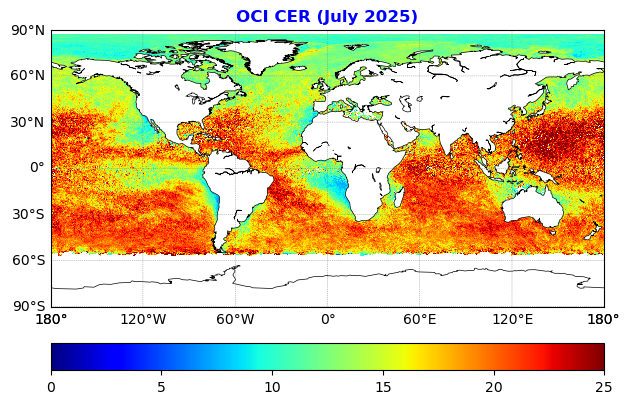

In [13]:
# Using Basemap
fig = plt.figure()
cmap = 'jet'

data = np.where(mask_all, OCI_CER, np.nan)
mean_data = np.nanmean(data, axis=0)

ax = Basemap(projection='cyl', lon_0=0, lat_0=0)
lon, lat = np.meshgrid(dataset_OCI.lon, dataset_OCI.lat)

mat = ax.pcolormesh(lon, lat, mean_data, cmap=cmap, vmin=0, vmax=25, shading="nearest", rasterized=True)

ax.fillcontinents(color='white')
ax.drawcoastlines(linewidth=0.5, color='black')

ax.drawparallels(np.arange(-90., 91., 30.), labels=[1,0,0,0], linewidth=0.3, color='gray', dashes=[3,2])
ax.drawmeridians(np.arange(-180.,181.,60.), labels=[0,0,0,1], linewidth=0.3, color='gray', dashes=[3,2])

plt.title('OCI CER (July 2025)', fontsize=12, color='b', fontweight='bold')
cax = plt.colorbar(mat, pad=0.08, orientation='horizontal')
# cax.set_label('CER')

plt.tight_layout()   
plt.savefig('Map_OCI_CER.png', dpi=500, bbox_inches="tight")
plt.show()

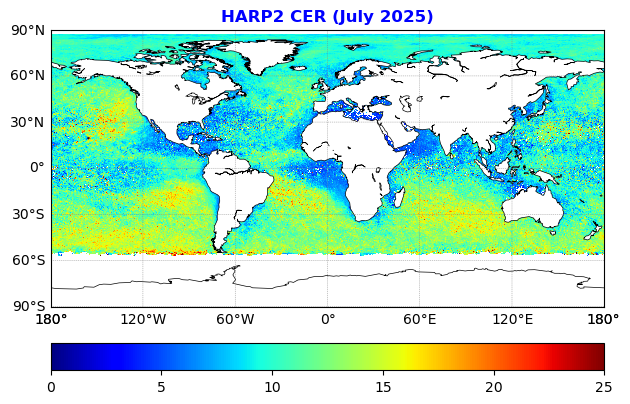

In [11]:
# Using Basemap
fig = plt.figure()
cmap = 'jet'

data = np.where(mask_all, HARP2_CER, np.nan)
mean_data = np.nanmean(data, axis=0)

ax = Basemap(projection='cyl', lon_0=0, lat_0=0)
lon, lat = np.meshgrid(dataset_OCI.lon, dataset_OCI.lat)

mat = ax.pcolormesh(lon, lat, mean_data, cmap=cmap, vmin=0, vmax=25, shading="nearest", rasterized=True)

ax.fillcontinents(color='white')
ax.drawcoastlines(linewidth=0.5, color='black')

ax.drawparallels(np.arange(-90., 91., 30.), labels=[1,0,0,0], linewidth=0.3, color='gray', dashes=[3,2])
ax.drawmeridians(np.arange(-180.,181.,60.), labels=[0,0,0,1], linewidth=0.3, color='gray', dashes=[3,2])

plt.title('HARP2 CER (July 2025)', fontsize=12, color='b', fontweight='bold')
cax = plt.colorbar(mat, pad=0.08, orientation='horizontal')
# cax.set_label('CER')

plt.tight_layout()
plt.savefig('Map_HARP2_CER.png', dpi=500, bbox_inches="tight")
plt.show()

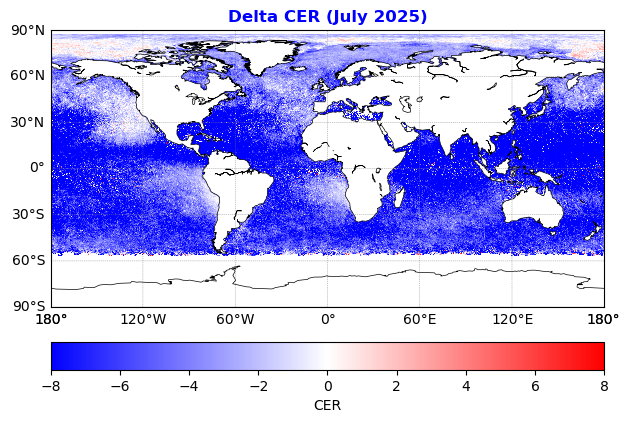

In [8]:
# Using Basemap
fig = plt.figure()
cmap='bwr'

OCI_CER = np.where(mask_all, OCI_CER, np.nan)
HARP2_CER = np.where(mask_all, HARP2_CER, np.nan)
delta_CER = HARP2_CER - OCI_CER

data = np.where(mask_all, delta_CER, np.nan)
mean_data = np.nanmean(data, axis=0)

ax = Basemap(projection='cyl', lon_0=0, lat_0=0)
lon, lat = np.meshgrid(dataset_OCI.lon, dataset_OCI.lat)

mat = ax.pcolormesh(lon, lat, mean_data, cmap=cmap, vmin=-8, vmax=8, shading="nearest", rasterized=True)

ax.fillcontinents(color='white')
ax.drawcoastlines(linewidth=0.5, color='black')

ax.drawparallels(np.arange(-90., 91., 30.), labels=[1,0,0,0], linewidth=0.3, color='gray', dashes=[3,2])
ax.drawmeridians(np.arange(-180.,181.,60.), labels=[0,0,0,1], linewidth=0.3, color='gray', dashes=[3,2])

plt.title('Delta CER (July 2025)', fontsize=12, color='b', fontweight='bold')
cax = plt.colorbar(mat, pad=0.08, orientation='horizontal')
cax.set_label('CER')

plt.tight_layout()
# plt.savefig('Map_Delta_CER.png', dpi=500, bbox_inches="tight")
plt.show()

## CEV 

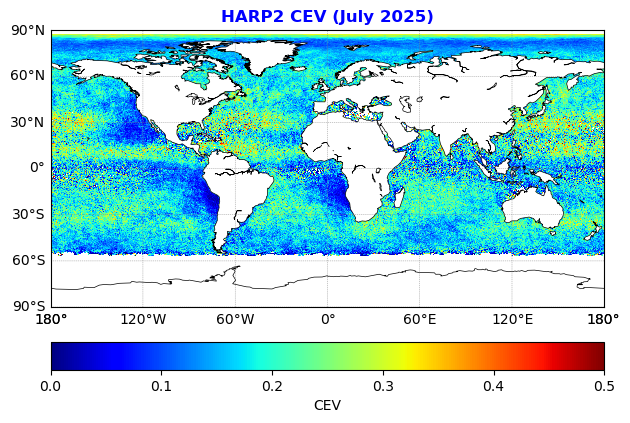

In [27]:
# Using Basemap
fig = plt.figure()
cmap = 'jet'

data = np.where(mask_all, HARP2_CEV, np.nan)
mean_data = np.nanmean(data, axis=0)

ax = Basemap(projection='cyl', lon_0=0, lat_0=0)
lon, lat = np.meshgrid(dataset_OCI.lon, dataset_OCI.lat)

mat = ax.pcolormesh(lon, lat, mean_data, cmap=cmap, vmin=0, vmax=0.5, shading="nearest", rasterized=True)

ax.fillcontinents(color='white')
ax.drawcoastlines(linewidth=0.5, color='black')

ax.drawparallels(np.arange(-90., 91., 30.), labels=[1,0,0,0], linewidth=0.3, color='gray', dashes=[3,2])
ax.drawmeridians(np.arange(-180.,181.,60.), labels=[0,0,0,1], linewidth=0.3, color='gray', dashes=[3,2])

plt.title('HARP2 CEV (July 2025)', fontsize=12, color='b', fontweight='bold')
cax = plt.colorbar(mat, pad=0.08, orientation='horizontal')
cax.set_label('CEV')

plt.tight_layout()
# plt.savefig('Map_HARP2_CEV.png', dpi=500, bbox_inches="tight")
plt.show()

## MODIS

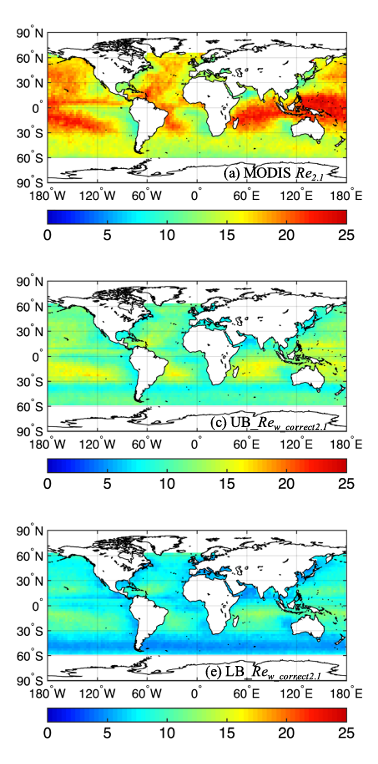